In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()          # a "Choose Files" button will appear
filename = list(uploaded.keys())[0]
print("Loaded file:", filename)

df = pd.read_csv(filename, encoding="latin-1")
print(df.columns.tolist())         # shows the column names
df.head()

Saving superstore.csv to superstore.csv
Loaded file: superstore.csv
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date", "Sales"]).drop_duplicates()

# Add up all sales for each week
weekly = (df.set_index("Order Date")["Sales"]
            .resample("W").sum().reset_index())
weekly.columns = ["date", "sales"]

print("Number of weeks:", len(weekly))
weekly.head()

Number of weeks: 209


,date,sales
0,2014-01-05,324.044
1,2014-01-12,4599.572
2,2014-01-19,4509.127
3,2014-01-26,3842.388
4,2014-02-02,1642.310


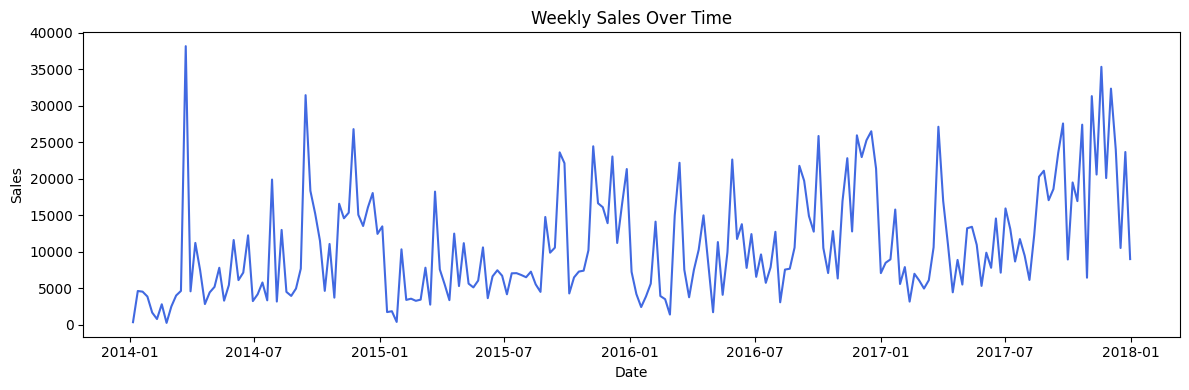

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(weekly["date"], weekly["sales"], color="royalblue")
plt.title("Weekly Sales Over Time")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("01_sales_trend.png", dpi=150)
plt.show()

In [ ]:
data = weekly.copy()
data["month"] = data["date"].dt.month
data["week"] = data["date"].dt.isocalendar().week.astype(int)
data["quarter"] = data["date"].dt.quarter
data["lag_1"] = data["sales"].shift(1)    # last week's sales
data["lag_4"] = data["sales"].shift(4)    # sales 4 weeks ago
data["roll_4"] = data["sales"].shift(1).rolling(4).mean()  # average of last 4 weeks
data = data.dropna().reset_index(drop=True)

features = ["month", "week", "quarter", "lag_1", "lag_4", "roll_4"]
print("Rows ready for the model:", len(data))
data.head()

Rows ready for the model: 205


,date,sales,month,week,quarter,lag_1,lag_4,roll_4
0,2014-02-02,1642.310,2,5,1,3842.388,324.044,3318.78275
1,2014-02-09,756.888,2,6,1,1642.310,4599.572,3648.34925
2,2014-02-16,2780.094,2,7,1,756.888,4509.127,2687.67825
3,2014-02-23,227.236,2,8,1,2780.094,3842.388,2255.42000
4,2014-03-02,2480.663,3,9,1,227.236,1642.310,1351.63200


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use the first 80% of weeks to learn, the last 20% to test
split = int(len(data) * 0.8)
train, test = data.iloc[:split], data.iloc[split:]

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(train[features], train["sales"])
pred = model.predict(test[features])

mae  = mean_absolute_error(test["sales"], pred)
rmse = np.sqrt(mean_squared_error(test["sales"], pred))
mape = np.mean(np.abs((test["sales"] - pred) / test["sales"])) * 100
print(f"MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | MAPE: {mape:.1f}%")plt.figure(figsize=(12,4))
plt.plot(test["date"], test["sales"], label="Actual", color="royalblue")
plt.plot(test["date"], pred, label="Predicted", color="orange")
plt.title("Actual vs Predicted Weekly Sales")
plt.legend(); plt.tight_layout()
plt.savefig("02_actual_vs_predicted.png", dpi=150)
plt.show()

MAE: 6,178 | RMSE: 8,057 | MAPE: 40.4%


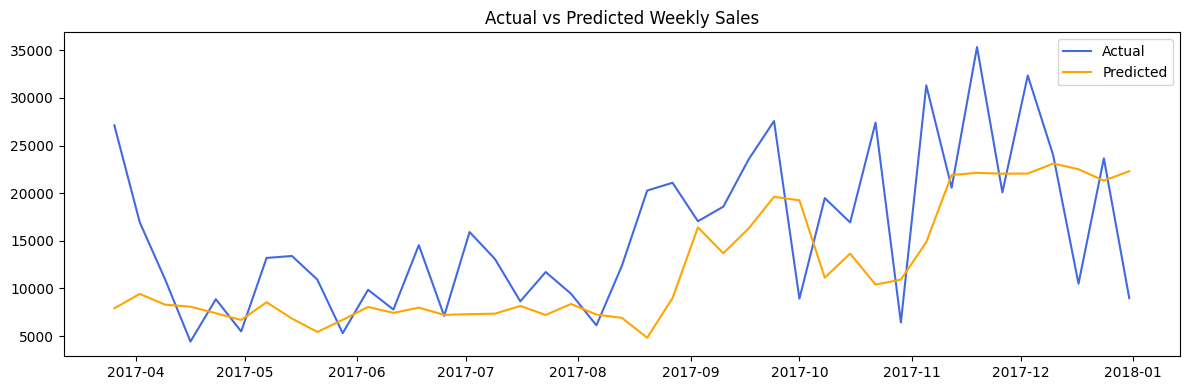

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(test["date"], test["sales"], label="Actual", color="royalblue")
plt.plot(test["date"], pred, label="Predicted", color="orange")
plt.title("Actual vs Predicted Weekly Sales")
plt.legend(); plt.tight_layout()
plt.savefig("02_actual_vs_predicted.png", dpi=150)
plt.show()

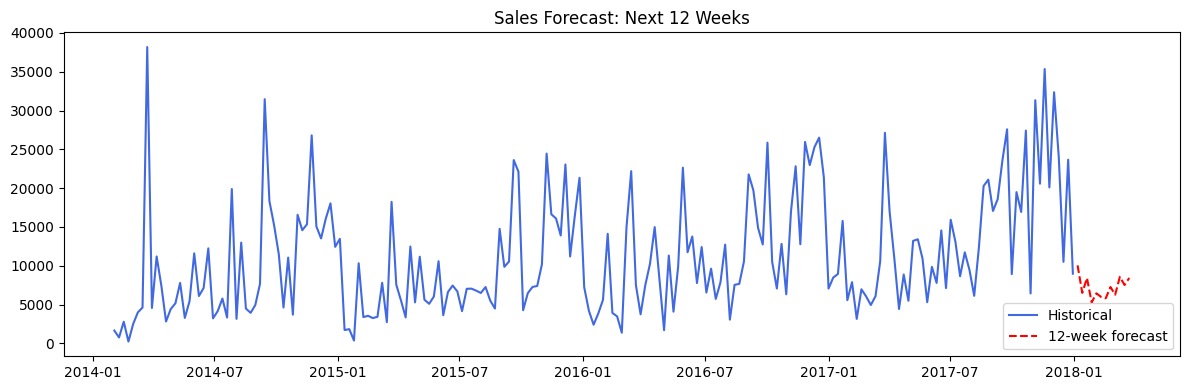

,date,forecast_sales
0,2018-01-07,10048.364385
1,2018-01-14,6501.561357
2,2018-01-21,8408.461131
3,2018-01-28,5263.240836
4,2018-02-04,6440.326157
5,2018-02-11,5979.305207
6,2018-02-18,5805.560949
7,2018-02-25,7254.181381
8,2018-03-04,6264.085125
9,2018-03-11,8568.301188


In [ ]:
history = data[["date", "sales"]].copy()
future_rows = []

for _ in range(12):
    next_date = history["date"].iloc[-1] + pd.Timedelta(weeks=1)
    row = {
        "month": next_date.month,
        "week": int(next_date.isocalendar().week),
        "quarter": (next_date.month - 1) // 3 + 1,
        "lag_1": history["sales"].iloc[-1],
        "lag_4": history["sales"].iloc[-4],
        "roll_4": history["sales"].iloc[-4:].mean(),
    }
    p = model.predict(pd.DataFrame([row])[features])[0]
    history.loc[len(history)] = [next_date, p]
    future_rows.append({"date": next_date, "forecast_sales": p})

future = pd.DataFrame(future_rows)
future.to_csv("future_forecast.csv", index=False)

plt.figure(figsize=(12,4))
plt.plot(data["date"], data["sales"], label="Historical", color="royalblue")
plt.plot(future["date"], future["forecast_sales"],
         label="12-week forecast", color="red", linestyle="--")
plt.title("Sales Forecast: Next 12 Weeks")
plt.legend(); plt.tight_layout()
plt.savefig("03_future_forecast.png", dpi=150)
plt.show()

future